In [1]:
# import autograd-wrapped numpy
import autograd.numpy as np
from autograd import grad
import matplotlib.pyplot as plt
from matplotlib import gridspec


# datapath to data
datapath = './mlrefined_datasets/superlearn_datasets/'

In [2]:
# load in dataset
csvname = datapath + '4class_data.csv'
data = np.loadtxt(csvname,delimiter = ',');

# get input/output pairs
x = data[:-1,:]
y = data[-1:,:] 

print(np.shape(x))
print(np.shape(y))

(2, 40)
(1, 40)


In [3]:
def model(x, w):
    a = w[0] + np.dot(x.T, w[1:])
    return a.T

def sigmoid(s):
    return 1 / (1 + np.exp(-s))

def softmax_cost(w, x, y):
    a = model(x, w)
    cost = np.sum(np.log(1 + np.exp(-y * a)))
    return cost / float(y.size)

def counting_cost(w, x, y):
    a = model(x, w)
    predictions = np.sign(a)
    
    cost = np.sum(np.abs(predictions - y) / 2.0)
    return cost / float(y.size)

def compute_gradient(w, x, y):
    a = model(x, w)
    sig = sigmoid(-y * a) 
    
    grad_w0 = -np.sum(y * sig)
    grad_w = -np.dot(x, (y * sig).T)
    
    gradient = np.vstack([[grad_w0], grad_w])
    return gradient / float(y.size)

def newton_method(g, w, x, y, max_its=100, tol=1e-6):
    weight_history = [w.copy()]
    cost_history = [g(w, x, y)]
    
    for k in range(max_its):
        a = model(x, w)
        sig = sigmoid(-y * a)
        
        grad = compute_gradient(w, x, y)
        
        sig_a = sigmoid(a)
        sig_neg_a = sigmoid(-a)
        diag = sig_a * sig_neg_a
        
        H_00 = np.sum(diag)
        H_ww = np.dot(x**2, diag.T) 
        
        H_diag = np.vstack([[H_00], H_ww]) / float(y.size)
        H_diag = H_diag + 1e-5 
        
        w = w - grad / H_diag
        
        current_cost = g(w, x, y)
        weight_history.append(w.copy())
        cost_history.append(current_cost)
        
        if k > 0 and abs(cost_history[-1] - cost_history[-2]) < tol:
            break
    
    return w, weight_history, cost_history

def train_ova(x, y, alpha=0.01, max_its=1000):
    classes = np.unique(y)
    C = len(classes)
    
    classifiers = []
    
    for c in classes:
        y_binary = np.where(y == c, 1, -1)
        
        best_w = None
        best_misclass = float('inf')
        
        for trial in range(3): 
            np.random.seed(trial * 42)
            w_init = np.random.randn(x.shape[0] + 1, 1) * 0.01
            
            w_final, weight_history, cost_history = newton_method(
                    softmax_cost, w_init, x, y_binary, 
                    max_its=100
                )
            
            misclass = counting_cost(w_final, x, y_binary)
            
            if misclass < best_misclass:
                best_misclass = misclass
                best_w = w_final
        
        classifiers.append(best_w)
    
    return classifiers, classes
            

def ova_predict(x, classifiers, classes):
    N = x.shape[1]
    scores = np.zeros((len(classes), N))
    
    for i, w in enumerate(classifiers):
        scores[i, :] = model(x, w).flatten()
    predictions = classes[np.argmax(scores, axis=0)]
    return predictions

In [4]:
classifiers, classes = train_ova(
        x, y, max_its=100
    )
predictions = ova_predict(x, classifiers, classes)
    
accuracy = np.mean(predictions == y.flatten())
misclassifications = np.sum(predictions != y.flatten())
    
print(f"Misclassifications: {misclassifications}")
 

Misclassifications: 8


/Users/mac/anaconda3/lib/python3.11/site-packages/autograd/tracer.py:54: RuntimeWarning: overflow encountered in exp
  return f_raw(*args, **kwargs)
/var/folders/_s/3v2gw63s7_50jb8yd4t_1zcc0000gn/T/ipykernel_35092/3204069491.py:56: RuntimeWarning: invalid value encountered in scalar subtract
  if k > 0 and abs(cost_history[-1] - cost_history[-2]) < tol:


In [11]:
# load in dataset
data = np.loadtxt(datapath + '3class_data.csv',delimiter = ',')

# get input/output pairs
x = data[:-1,:]
y = data[-1:,:]

print(np.shape(x))
print(np.shape(y))

(2, 30)
(1, 30)


In [15]:
def std_normalize(x):
    mean = np.mean(x, axis=1, keepdims=True)
    std = np.std(x, axis=1, keepdims=True)
    return (x - mean) / (std + 1e-10)

lam = 10**-5 
def model(x, w):
    return np.dot(w.T, x)

def multiclass_perceptron(w):
    all_evals = model(x, w)
    a = np.max(all_evals, axis=0)
    b = all_evals[y.astype(int).flatten(), np.arange(np.size(y))]
    cost = np.sum(a - b)
    
    cost = cost + lam*np.linalg.norm(w[1:, :], 'fro')**2
    
    return cost/float(np.size(y))

def compute_grad(w):
    num_samples = x.shape[1]
    grad = np.zeros_like(w)
    
    all_evals = model(x, w)
    
    for p in range(num_samples):
        y_p = int(y[0, p])
        scores = all_evals[:, p]
        scores_diff = scores - scores[y_p]
        scores_diff[y_p] = -np.inf
        j_max = np.argmax(scores_diff)
        
        if scores_diff[j_max] > 0:
            grad[:, j_max] += x[:, p]
            grad[:, y_p] -= x[:, p]
    
    grad = grad / float(num_samples)
    grad[1:, :] += 2*lam*w[1:, :]
    
    return grad

def gradient_descent(g, alpha, max_its, w):
    weight_history = [w]
    cost_history = [g(w)]
    
    for _ in range(max_its):
        grad_eval = compute_grad(w)
        w = w - alpha * grad_eval
        weight_history.append(w)
        cost_history.append(g(w))
    
    return weight_history, cost_history

num_classes = int(np.max(y)) + 1
w = 0.1 * np.random.randn(x.shape[0], num_classes)

alpha = 0.1 
max_its = 1000

weight_history, cost_history = gradient_descent(multiclass_perceptron, alpha, max_its, w)

w = weight_history[-1]

inds = np.argmax(model(x, w), axis=0)
misses = np.count_nonzero(inds - y)

print(f"\nMisclassifications: {misses}")



Misclassifications: 0



ONE-VERSUS-ALL (OvA) MULTI-CLASS CLASSIFICATION

Training 4 binary classifiers using newton method...

Training classifier for class 0...
  Best misclassification rate: 0.1250

Training classifier for class 1...
  Best misclassification rate: 0.1750

Training classifier for class 2...
  Best misclassification rate: 0.2000

Training classifier for class 3...
  Best misclassification rate: 0.1250

OVERALL RESULTS:
Total samples: 40
Correct predictions: 32
Misclassifications: 8
Accuracy: 80.00%
Error rate: 20.00%

✓ SUCCESS: Misclassifications < 10 (requirement met!)


/Users/mac/anaconda3/lib/python3.11/site-packages/autograd/tracer.py:54: RuntimeWarning: overflow encountered in exp
  return f_raw(*args, **kwargs)
/var/folders/_s/3v2gw63s7_50jb8yd4t_1zcc0000gn/T/ipykernel_30679/1094743279.py:154: RuntimeWarning: invalid value encountered in scalar subtract
  if k > 0 and abs(cost_history[-1] - cost_history[-2]) < tol:


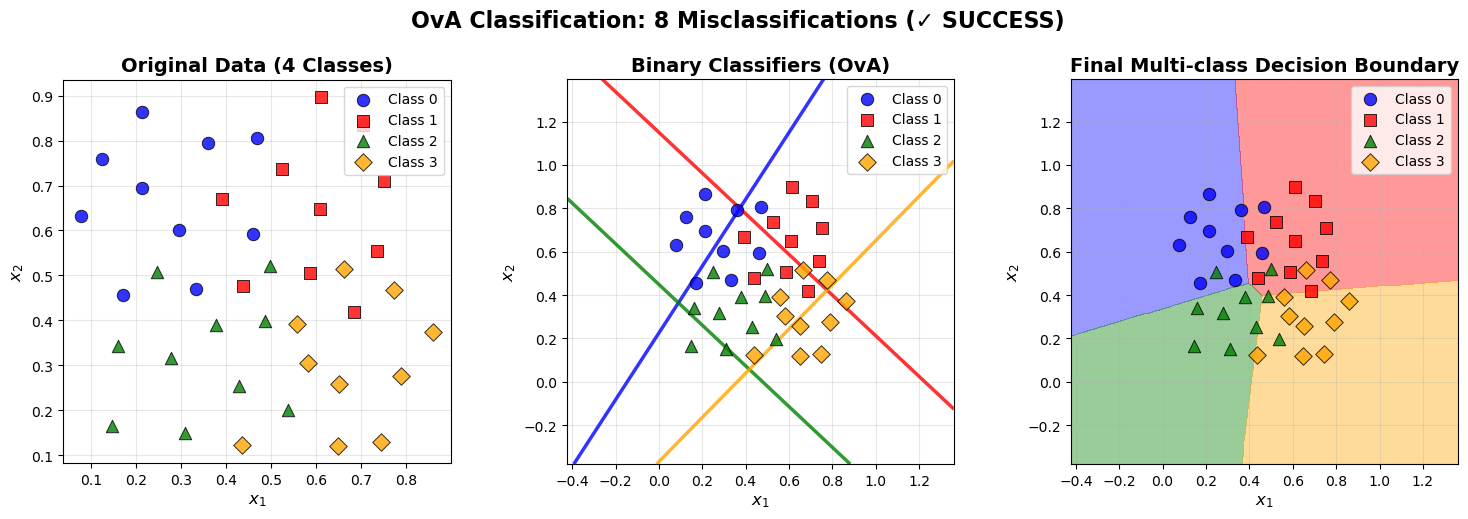

In [7]:
def model(x, w):
    a = w[0] + np.dot(x.T, w[1:])
    return a.T

def sigmoid(s):
    return 1 / (1 + np.exp(-s))

def softmax_cost(w, x, y):
    a = model(x, w)
    cost = np.sum(np.log(1 + np.exp(-y * a)))
    return cost / float(y.size)

def counting_cost(w, x, y):
    a = model(x, w)
    predictions = np.sign(a)
    
    cost = np.sum(np.abs(predictions - y) / 2.0)
    return cost / float(y.size)


def compute_gradient(w, x, y):
    a = model(x, w)
    sig = sigmoid(-y * a) 
    
    grad_w0 = -np.sum(y * sig)
    grad_w = -np.dot(x, (y * sig).T)
    
    gradient = np.vstack([[grad_w0], grad_w])
    return gradient / float(y.size)

def gradient_descent_with_momentum(g, w, x, y, alpha=0.1, max_its=5000, 
                                   beta=0.9, tol=1e-8):
    """
    Gradient descent with momentum for better convergence
    
    Parameters:
    -----------
    g : cost function
    w : initial weights of shape (D+1, 1)
    x : input features of shape (D, N)
    y : labels of shape (1, N)
    alpha : learning rate
    max_its : maximum iterations
    beta : momentum coefficient
    tol : tolerance for convergence
    """
    # initialize
    weight_history = [w.copy()]
    cost_history = [g(w, x, y)]
    velocity = np.zeros_like(w)
    
    best_w = w.copy()
    best_cost = cost_history[0]
    patience = 100
    no_improve_count = 0
    
    # main loop
    for k in range(max_its):
        # compute gradient
        grad = compute_gradient(w, x, y)
        
        # update velocity with momentum
        velocity = beta * velocity + (1 - beta) * grad
        
        # take step
        w = w - alpha * velocity
        
        # record
        current_cost = g(w, x, y)
        weight_history.append(w.copy())
        cost_history.append(current_cost)
        
        # track best weights
        if current_cost < best_cost:
            best_cost = current_cost
            best_w = w.copy()
            no_improve_count = 0
        else:
            no_improve_count += 1
        
        # early stopping
        if no_improve_count >= patience:
            print(f"  Early stopping at iteration {k}")
            break
        
        # check convergence
        if k > 0 and abs(cost_history[-1] - cost_history[-2]) < tol:
            print(f"  Converged at iteration {k}")
            break
    
    if k == max_its - 1:
        print(f"  Reached max iterations: {max_its}")
    
    return best_w, weight_history, cost_history

def newton_method(g, w, x, y, max_its=100, tol=1e-6):
    weight_history = [w.copy()]
    cost_history = [g(w, x, y)]
    
    for k in range(max_its):
        a = model(x, w)
        sig = sigmoid(-y * a)
        
        grad = compute_gradient(w, x, y)
        
        sig_a = sigmoid(a)
        sig_neg_a = sigmoid(-a)
        diag = sig_a * sig_neg_a
        
        H_00 = np.sum(diag)
        H_ww = np.dot(x**2, diag.T) 
        
        H_diag = np.vstack([[H_00], H_ww]) / float(y.size)
        H_diag = H_diag + 1e-5 
        
        w = w - grad / H_diag
        
        current_cost = g(w, x, y)
        weight_history.append(w.copy())
        cost_history.append(current_cost)
        
        if k > 0 and abs(cost_history[-1] - cost_history[-2]) < tol:
            print(f"  Newton converged at iteration {k}")
            break
    
    return w, weight_history, cost_history

def train_ova_classifiers(x, y, method='newton', alpha=1.0, max_its=5000):
    # get unique classes
    classes = np.unique(y)
    C = len(classes)
    
    print(f"Training {C} binary classifiers using {method} method...")
    
    classifiers = []
    
    # train one binary classifier for each class
    for c in classes:
        print(f"\nTraining classifier for class {int(c)}...")
        
        # create binary labels: +1 for class c, -1 for all others
        y_binary = np.where(y == c, 1, -1)
        
        # Try multiple random initializations and pick the best
        best_w = None
        best_misclass = float('inf')
        
        for trial in range(3):  # Try 3 different initializations
            # initialize weights
            np.random.seed(trial * 42)
            w_init = np.random.randn(x.shape[0] + 1, 1) * 0.01
            
            # train classifier
            if method == 'newton':
                w_final, weight_history, cost_history = newton_method(
                    softmax_cost, w_init, x, y_binary, 
                    max_its=100
                )
            else:  # momentum
                w_final, weight_history, cost_history = gradient_descent_with_momentum(
                    softmax_cost, w_init, x, y_binary, 
                    alpha=alpha, max_its=max_its
                )
            
            # check performance
            misclass = counting_cost(w_final, x, y_binary)
            
            if misclass < best_misclass:
                best_misclass = misclass
                best_w = w_final
        
        classifiers.append(best_w)
        print(f"  Best misclassification rate: {best_misclass:.4f}")
    
    return classifiers, classes

# ============================================
# Part 5: OvA Prediction
# ============================================

def ova_predict(x, classifiers, classes):
    """
    Make predictions using OvA fusion rule
    """
    N = x.shape[1]
    scores = np.zeros((len(classes), N))
    
    # compute score from each classifier
    for i, w in enumerate(classifiers):
        scores[i, :] = model(x, w).flatten()
    
    # predict class with highest score
    predictions = classes[np.argmax(scores, axis=0)]
    return predictions

# ============================================
# Part 6: Visualization Functions
# ============================================

def plot_data(x, y, ax):
    """Plot the 4-class dataset"""
    classes = np.unique(y)
    colors = ['blue', 'red', 'green', 'orange']
    markers = ['o', 's', '^', 'D']
    
    for i, c in enumerate(classes):
        idx = (y == c).flatten()
        ax.scatter(x[0, idx], x[1, idx], c=colors[i], 
                  marker=markers[i], s=80, edgecolors='k', 
                  linewidths=0.7, label=f'Class {int(c)}', 
                  zorder=3, alpha=0.8)
    
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

def plot_decision_boundaries(x, y, classifiers, classes, ax):
    """Plot decision boundaries for each binary classifier"""
    colors = ['blue', 'red', 'green', 'orange']
    
    # create grid
    margin = 0.5
    x1_min, x1_max = x[0, :].min() - margin, x[0, :].max() + margin
    x2_min, x2_max = x[1, :].min() - margin, x[1, :].max() + margin
    x1_grid, x2_grid = np.meshgrid(
        np.linspace(x1_min, x1_max, 400),
        np.linspace(x2_min, x2_max, 400)
    )
    
    # plot decision boundary for each classifier
    for i, w in enumerate(classifiers):
        x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel()])
        scores = model(x_grid, w).reshape(x1_grid.shape)
        
        ax.contour(x1_grid, x2_grid, scores, levels=[0],
                  colors=colors[i], linewidths=2.5, alpha=0.8,
                  linestyles='solid')
    
    # plot data points
    plot_data(x, y, ax)
    ax.set_title('Binary Classifiers (OvA)', fontsize=14, fontweight='bold')
    ax.set_xlim([x1_min, x1_max])
    ax.set_ylim([x2_min, x2_max])

def plot_final_decision(x, y, classifiers, classes, ax):
    """Plot final multi-class decision boundary"""
    colors_map = ['blue', 'red', 'green', 'orange']
    
    # create grid
    margin = 0.5
    x1_min, x1_max = x[0, :].min() - margin, x[0, :].max() + margin
    x2_min, x2_max = x[1, :].min() - margin, x[1, :].max() + margin
    x1_grid, x2_grid = np.meshgrid(
        np.linspace(x1_min, x1_max, 400),
        np.linspace(x2_min, x2_max, 400)
    )
    
    # predict class for each grid point
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel()])
    predictions = ova_predict(x_grid, classifiers, classes)
    predictions_grid = predictions.reshape(x1_grid.shape)
    
    # plot colored regions
    for i, c in enumerate(classes):
        mask = (predictions_grid == c)
        ax.contourf(x1_grid, x2_grid, mask.astype(float),
                   levels=[0.5, 1.5], colors=[colors_map[i]], 
                   alpha=0.4)
    
    # plot data points
    plot_data(x, y, ax)
    ax.set_title('Final Multi-class Decision Boundary', fontsize=14, fontweight='bold')
    ax.set_xlim([x1_min, x1_max])
    ax.set_ylim([x2_min, x2_max])

# ============================================
# Part 7: Main Execution
# ============================================

def main():
    print("\n" + "="*60)
    print("ONE-VERSUS-ALL (OvA) MULTI-CLASS CLASSIFICATION")
    print("="*60 + "\n")
    
    # Train OvA classifiers using Newton's method (more powerful)
    classifiers, classes = train_ova_classifiers(
        x, y, method='newton', max_its=100
    )
    
    # Make predictions
    predictions = ova_predict(x, classifiers, classes)
    
    # Compute overall accuracy
    accuracy = np.mean(predictions == y.flatten())
    misclassifications = np.sum(predictions != y.flatten())
    
    print(f"\n{'='*60}")
    print(f"OVERALL RESULTS:")
    print(f"{'='*60}")
    print(f"Total samples: {len(y.flatten())}")
    print(f"Correct predictions: {len(y.flatten()) - misclassifications}")
    print(f"Misclassifications: {misclassifications}")
    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"Error rate: {(1-accuracy)*100:.2f}%")
    print(f"{'='*60}\n")
    
    # Check if requirement is met
    if misclassifications < 10:
        print("✓ SUCCESS: Misclassifications < 10 (requirement met!)")
    else:
        print(f"✗ WARNING: Misclassifications = {misclassifications} >= 10")
        print("  Trying with momentum-based gradient descent...")
        
        # Try alternative method
        classifiers_alt, _ = train_ova_classifiers(
            x, y, method='momentum', alpha=2.0, max_its=10000
        )
        predictions_alt = ova_predict(x, classifiers_alt, classes)
        misclass_alt = np.sum(predictions_alt != y.flatten())
        
        if misclass_alt < misclassifications:
            print(f"\n  Improved! New misclassifications: {misclass_alt}")
            classifiers = classifiers_alt
            predictions = predictions_alt
            misclassifications = misclass_alt
    
    # Create visualization
    fig = plt.figure(figsize=(18, 5))
    gs = gridspec.GridSpec(1, 3, wspace=0.3)
    
    # Plot 1: Original data
    ax1 = plt.subplot(gs[0])
    plot_data(x, y, ax1)
    ax1.set_title('Original Data (4 Classes)', fontsize=14, fontweight='bold')
    
    # Plot 2: Binary classifiers
    ax2 = plt.subplot(gs[1])
    plot_decision_boundaries(x, y, classifiers, classes, ax2)
    
    # Plot 3: Final decision boundary
    ax3 = plt.subplot(gs[2])
    plot_final_decision(x, y, classifiers, classes, ax3)
    
    status = "✓ SUCCESS" if misclassifications < 10 else "✗ NEEDS IMPROVEMENT"
    plt.suptitle(f'OvA Classification: {misclassifications} Misclassifications ({status})', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    plt.savefig('ova_classification_result.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return classifiers, predictions, accuracy

# Run the main function
if __name__ == "__main__":
    classifiers, predictions, accuracy = main()

In [2]:
# compute linear combination of input points 
def model(x, w):
    a = w[0] + np.dot(x.T, w[1:])
    return a.T

# an implementation of the least squares cost function for linear regression
def least_squares(w):
    cost = np.sum((model(x, w) - y)**2)
    return cost / float(y.size)


def gradient_descent(g, alpha, max_its, w):
    grad_g = grad(g)
    
    weights = [w]
    cost_history = [g(w)]
    
    for k in range(max_its):
        gradient = grad_g(w)       
        w = w - alpha * gradient   
        
        weights.append(w)
        cost_history.append(g(w))
        
    return weights, cost_history

In [3]:
# import the dataset
csvname = datapath + 'kleibers_law_data.csv'
data = np.loadtxt(csvname,delimiter=',')
x = data[:-1,:]
y = data[-1:,:]

print(np.shape(x))
print(np.shape(y))

(1, 1498)
(1, 1498)


In [4]:
x= np.log(x)
y = np.log(y)

w_initial = np.random.randn(2, 1)*0.1

alpha = 0.01
max_its = 1000

weight, cost_hist = gradient_descent(least_squares, alpha, max_its, w_initial)

weight[-1]

array([[6.81472345],
       [0.65280991]])

In [5]:
# 取最优参数
w0 = weight[-1][0][0]
w1 = weight[-1][1][0]

# 非线性关系
A = np.exp(w0)
b = w1

print(f"Nonlinear model: y = {A:.3f} * x^{b:.3f}")


Nonlinear model: y = 911.165 * x^0.653


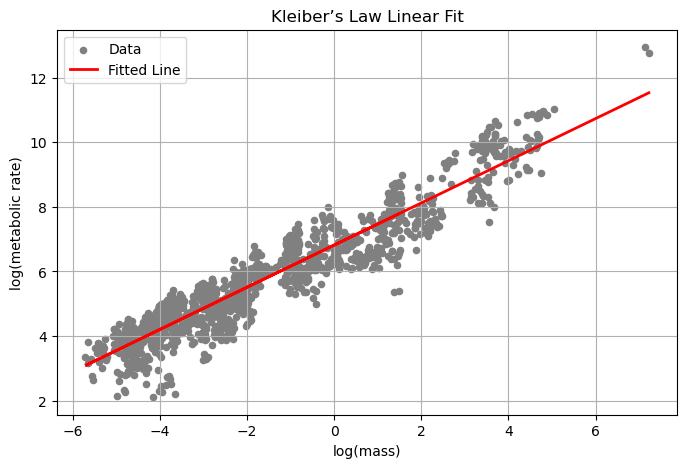

In [6]:
import matplotlib.pyplot as plt

# 如果之前 log(x), log(y) 被覆盖，这里再取一次即可
x_log = x
y_log = y

# 获取最优参数
w0 = weight[-1][0][0]
w1 = weight[-1][1][0]

# 拟合线
y_fit = w0 + w1 * x_log

# 画图
plt.figure(figsize=(8, 5))
plt.scatter(x_log.flatten(), y_log.flatten(), color='gray', s=20, label='Data')
plt.plot(x_log.flatten(), y_fit.flatten(), color='red', linewidth=2, label='Fitted Line')

plt.xlabel("log(mass)")
plt.ylabel("log(metabolic rate)")
plt.title("Kleiber’s Law Linear Fit")
plt.legend()
plt.grid(True)
plt.show()


In [7]:
x_test = 10  # kg
y_pred = A * (x_test ** b)
print(f"Predicted metabolic rate: {y_pred:.2f} kJ/day")


Predicted metabolic rate: 4096.44 kJ/day


In [8]:
calories = y_pred * 239
print(f"≈ {calories:.2f} calories/day")


≈ 979049.39 calories/day


In [9]:
# import the dataset
csvname =  datapath + 'boston_housing.csv'
data = np.loadtxt(csvname,delimiter=',')
x = data[:-1,:]
y = data[-1:,:]

print(np.shape(x))
print(np.shape(y))

(13, 506)
(1, 506)


In [3]:
def standard_normalize(x):
    mu = np.mean(x, axis=1, keepdims=True)
    sigma = np.std(x, axis=1, keepdims=True)
    x_norm = (x - mu) / sigma
    return x_norm

def least_absolute_deviations(w):
    cost = np.sum(np.abs(model(x, w) - y))
    return cost / float(y.size)


In [11]:
x = standard_normalize(x)


w_init = 0.1 * np.random.randn(x.shape[0] + 1, 1)
alpha = 0.1
max_its = 1000

weight, cost0 = gradient_descent(least_squares, alpha, max_its, w_init)
cost0 = np.sqrt(cost0[-1])

weight, cost1 = gradient_descent(least_absolute_deviations, alpha, max_its, w_init)

cost0, cost1[-1]-【

(4.6795063006360555, 3.088936561104436)

In [3]:
csvname = datapath + 'boston_housing.csv'
data = np.loadtxt(csvname, delimiter=',')
x_boston = data[:-1, :]
y_boston = data[-1:, :]
print('Boston:', np.shape(x_boston), np.shape(y_boston))

csvname = datapath + 'auto_data.csv'
data = np.loadtxt(csvname, delimiter=',')
x_auto = data[:-1, :]
y_auto = data[-1:, :]
print('Auto:', np.shape(x_auto), np.shape(y_auto))

datasets = {
    "Boston Housing": (x_boston, y_boston),
    "Auto MPG": (x_auto, y_auto)
}


Boston: (13, 506) (1, 506)
Auto: (7, 398) (1, 398)


In [4]:

def standard_normalize(x):
    mu = np.nanmean(x, axis=1, keepdims=True)
    sigma = np.nanstd(x, axis=1, keepdims=True)
    
    nan_mask = np.isnan(x)
    x[nan_mask] = np.take(mu, np.where(nan_mask)[0])
    
    x_norm = (x - mu) / sigma
    return x_norm

def least_absolute_deviations(w):
    cost = np.sum(np.abs(model(x, w) - y))
    return cost / float(y.size)



In [5]:

results = {}

for name, (x_raw, y_raw) in datasets.items():
    print(f"\n=== Running on: {name} ===")
    
    x = standard_normalize(x_raw)
    y = y_raw

    w_init = 0.1 * np.random.randn(x.shape[0] + 1, 1)
    alpha = 0.1
    max_its = 1000

    # RMSE = sqrt(MSE)
    weight, cost_mse = gradient_descent(least_squares, alpha, max_its, w_init)
    rmse = np.sqrt(np.array(cost_mse))

    # MAD
    weight, cost_mad = gradient_descent(least_absolute_deviations, alpha, max_its, w_init)
    mad = np.array(cost_mad)

    results[name] = {
        "rmse_curve": rmse,
        "mad_curve": mad,
        "rmse": rmse[-1],
        "mad": mad[-1]
    }

    # Print final values
    print(f"RMSE: {rmse[-1]:.5f}")
    print(f"MAD : {mad[-1]:.5f}")



=== Running on: Boston Housing ===
RMSE: 4.67951
MAD : 3.08978

=== Running on: Auto MPG ===
RMSE: 3.30357
MAD : 2.45826


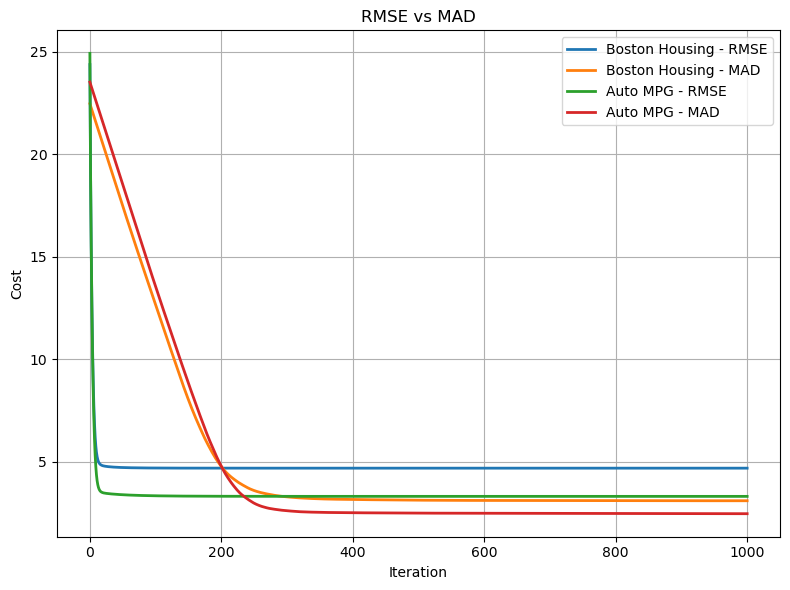

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name in results:
    plt.plot(results[name]['rmse_curve'], label=f"{name} - RMSE", linewidth=2)
    plt.plot(results[name]['mad_curve'], label=f"{name} - MAD", linewidth=2)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("RMSE vs MAD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [15]:
csvname = datapath + '2d_classification_data_v1_entropy.csv'
data = np.loadtxt(csvname,delimiter = ',')

x = data[:-1,:]
y = data[-1:,:] 

print(np.shape(x))
print(np.shape(y))

(1, 11)
(1, 11)


In [18]:
def model(x, w):
    a = w[0] + np.dot(x.T, w[1:])  
    return a.T  

def sigmoid(t):
    return 1 / (1 + np.exp(-t))

def cross_entropy(w):
    a = sigmoid(model(x, w))
    
    ind_0 = np.argwhere(y == 0)[:, 1]  
    cost = -np.sum(np.log(1 - a[:, ind_0]))
    
    ind_1 = np.argwhere(y == 1)[:, 1]  
    cost -= np.sum(np.log(a[:, ind_1]))
    
    return cost / y.size

compute_grad = grad(cross_entropy)

def gradient_descent(g, alpha, max_its, w):
    weight_history = [w]
    cost_history = [g(w)]
    
    for _ in range(max_its):
        grad_eval = compute_grad(w)
        w = w - alpha * grad_eval
        weight_history.append(w)
        cost_history.append(g(w))
    
    return weight_history, cost_history


In [21]:
w_init = np.array([[3.0], [3.0]])  
alpha = 1  
max_its =2000

weights, costs = gradient_descent(cross_entropy, alpha, max_its, w_init)
final_w = weights[-1]

costs[-1]

0.08096010450013466

/var/folders/_s/3v2gw63s7_50jb8yd4t_1zcc0000gn/T/ipykernel_26145/2003801103.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


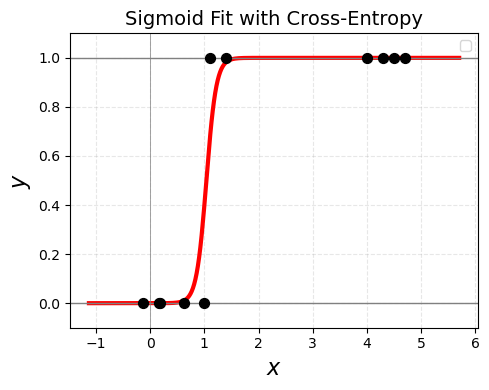

In [28]:
fig, ax = plt.subplots(figsize=(5, 4))

class_0_x = x[0, y[0] == 0]
class_1_x = x[0, y[0] == 1]

ax.scatter(class_0_x, np.zeros_like(class_0_x), 
           c='black', edgecolor='black', s=50, zorder=3)
ax.scatter(class_1_x, np.ones_like(class_1_x), 
           c='black', edgecolor='black', s=50, zorder=3)

x_plot = np.linspace(np.min(x) - 1, np.max(x) + 1, 300).reshape(1, -1)
y_pred = sigmoid(model(x_plot, final_w))

ax.plot(x_plot.ravel(), y_pred.ravel(), 
        color='red', linewidth=3)

ax.axhline(0, color='gray', lw=1)
ax.axhline(1, color='gray', lw=1)
ax.axvline(0, color='gray', lw=0.5)

ax.set_xlabel(r"$x$", fontsize=16)
ax.set_ylabel(r"$y$", fontsize=16)
ax.set_ylim([-0.1, 1.1])
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_title("Sigmoid Fit with Cross-Entropy", fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

In [1]:
# import autograd-wrapped numpy
import autograd.numpy as np
from autograd import grad
import matplotlib.pyplot as plt

# datapath to data
datapath = './mlrefined_datasets/superlearn_datasets/'

In [6]:
csvname = datapath + 'breast_cancer_data.csv'
data = np.loadtxt(csvname, delimiter=',')

x = data[:-1, :]
y = data[-1:, :] 
print("Input shape:", np.shape(x))
print("Output shape:", np.shape(y))

Input shape: (8, 699)
Output shape: (1, 699)


In [2]:
def model(x, w):
    a = w[0] + np.dot(x.T, w[1:])  
    return a.T  

def softmax_cost(w):
    predictions = model(x, w) 
    cost = np.sum(np.log(1 + np.exp(-y * predictions)))
    return cost / float(np.size(y))

def perceptron_cost(w):
    predictions = model(x, w) 
    cost = np.sum(np.maximum(0, -y * predictions))
    return cost / float(np.size(y))

def gradient_descent(g, alpha, max_its, w):
    grad_g = grad(g)
    
    weights = [w]
    cost_history = [g(w)]
    
    for k in range(max_its):
        gradient = grad_g(w)       
        w = w - alpha * gradient   
        
        weights.append(w)
        cost_history.append(g(w))
        
    return weights, cost_history

def count_misclassifications(w, x, y):
    predictions = model(x, w) 
    y_hat = np.sign(predictions)
    miss = np.argwhere(y_hat != y)
    miss = [i[1] for i in miss]
    cost = np.sum(len(miss))
    return cost

In [7]:
n_features = x.shape[0]
w_init = 0.1 * np.random.randn(n_features + 1, 1)
alpha = 1  
max_its = 1000

weights_softmax, costs_softmax = gradient_descent(softmax_cost, alpha, max_its, w_init)

count_softmax = [count_misclassifications(u, x, y) for u in weights_softmax]
miss_softmax = np.min(count_softmax)

weights_perceptron, costs_perceptron = gradient_descent(perceptron_cost, alpha, max_its, w_init)

count_perceptron = [count_misclassifications(u, x, y) for u in weights_perceptron]
miss_perceptron = np.min(count_perceptron)

miss_softmax, miss_perceptron

(21, 20)

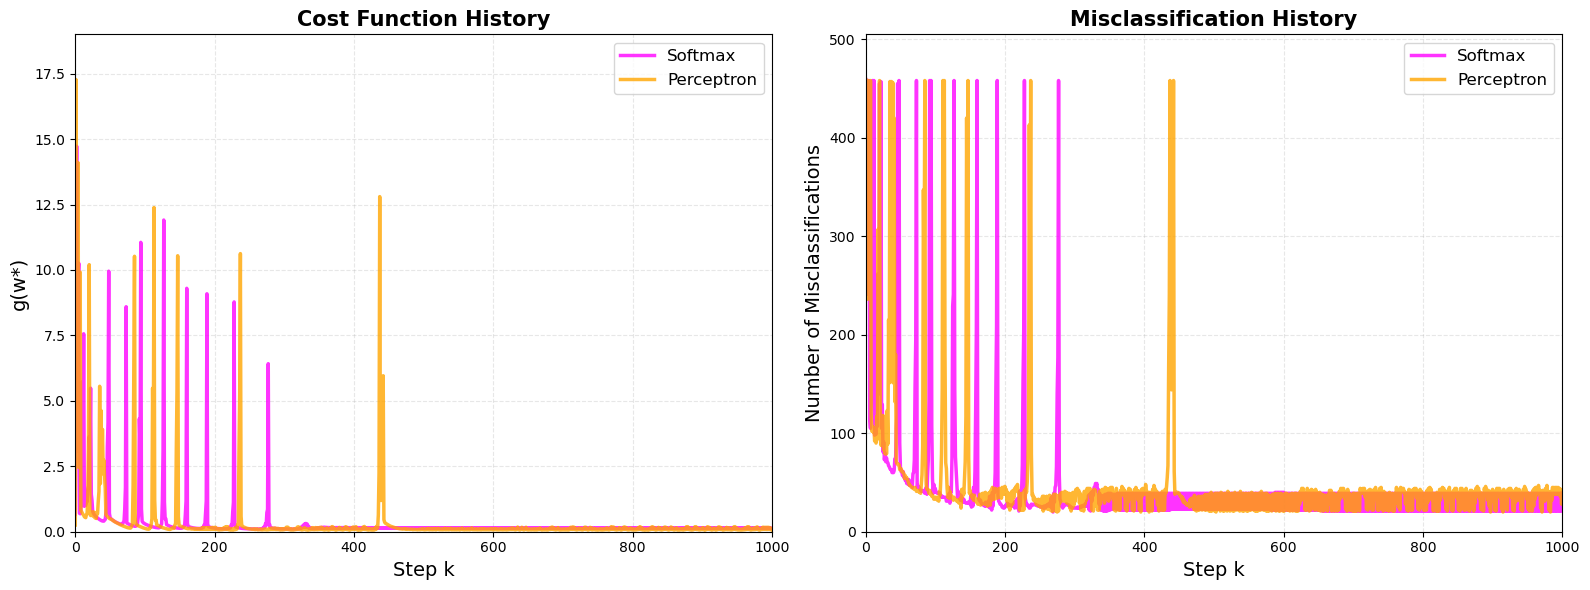

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Cost function history
ax = axes[0]
ax.plot(costs_softmax, linewidth=2.5, color='magenta', label='Softmax', alpha=0.8)
ax.plot(costs_perceptron, linewidth=2.5, color='orange', label='Perceptron', alpha=0.8)
ax.set_xlabel('Step k', fontsize=14)
ax.set_ylabel('g(w*)', fontsize=14)
ax.set_title('Cost Function History', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim([0, max_its])
# 设置 y 轴范围以更好地显示
if max(costs_softmax) < 20:  # 如果成本值较小
    ax.set_ylim([0, max(max(costs_softmax), max(costs_perceptron)) * 1.1])

# Right panel: Misclassification history
ax = axes[1]
ax.plot(count_softmax, linewidth=2.5, color='magenta', label='Softmax', alpha=0.8)
ax.plot(count_perceptron, linewidth=2.5, color='orange', label='Perceptron', alpha=0.8)
ax.set_xlabel('Step k', fontsize=14)
ax.set_ylabel('Number of Misclassifications', fontsize=14)
ax.set_title('Misclassification History', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim([0, max_its])
ax.set_ylim([0, max(max(count_softmax), max(count_perceptron)) * 1.1])

plt.tight_layout()
plt.savefig('exercise_6_13_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
csvname = datapath + 'spambase_data.csv'
data = np.loadtxt(csvname,delimiter = ',')

x = data[:-1,:]
y = data[-1:,:] 

print(np.shape(x))
print(np.shape(y))

(57, 4601)
(1, 4601)


In [4]:
def standard_normalize(x):
    mu = np.mean(x, axis=1, keepdims=True)
    sigma = np.std(x, axis=1, keepdims=True)
    x_norm = (x - mu) / sigma
    return x_norm

In [5]:
x = standard_normalize(x)

n_features = x.shape[0]
w_init = 0.1 * np.random.randn(n_features + 1, 1)
alpha = 0.1  
max_its = 1000  

weights_softmax, costs_softmax = gradient_descent(softmax_cost, alpha, max_its, w_init)
count_softmax = [count_misclassifications(u, x, y) for u in weights_softmax]
miss_softmax = np.min(count_softmax)
accuracy_softmax = 100 * (1 - miss_softmax / y.size)

print(f"Softmax - Minimum misclassifications: {miss_softmax}")
print(f"Softmax - Best accuracy: {accuracy_softmax:.2f}%")


weights_perceptron, costs_perceptron = gradient_descent(perceptron_cost, alpha, max_its, w_init)
count_perceptron = [count_misclassifications(u, x, y) for u in weights_perceptron]
miss_perceptron = np.min(count_perceptron)
accuracy_perceptron = 100 * (1 - miss_perceptron / y.size)

print(f"Perceptron - Minimum misclassifications: {miss_perceptron}")
print(f"Perceptron - Best accuracy: {accuracy_perceptron:.2f}%")


Softmax - Minimum misclassifications: 349
Softmax - Best accuracy: 92.41%
Perceptron - Minimum misclassifications: 333
Perceptron - Best accuracy: 92.76%


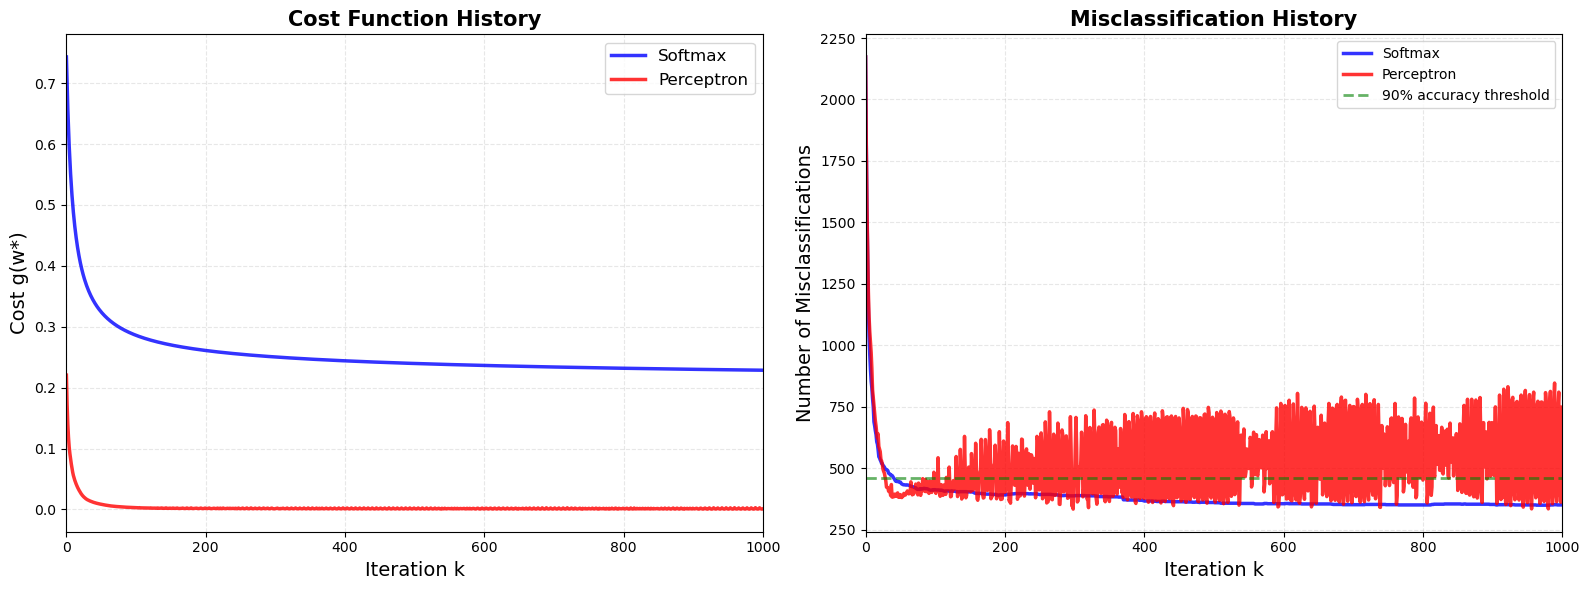


FINAL RESULTS - Exercise 6.14
Dataset: Spam Detection (Spambase)
  - Number of samples (P): 4601
  - Number of features (N): 57
  - Data preprocessing: Standard normalization applied

----------------------------------------------------------------------
SOFTMAX Cost Function
----------------------------------------------------------------------
  Initial cost:        0.743134
  Final cost:          0.228650
  Initial misclass:    2173 (47.23%)
  Final misclass:      350 (7.61%)
  Minimum misclass:    349 (7.59%)
  ★ BEST ACCURACY:     92.41%

----------------------------------------------------------------------
PERCEPTRON Cost Function
----------------------------------------------------------------------
  Initial cost:        0.220597
  Final cost:          0.001226
  Initial misclass:    2173 (47.23%)
  Final misclass:      748 (16.26%)
  Minimum misclass:    333 (7.24%)
  ★ BEST ACCURACY:     92.76%

COMPARISON & CONCLUSION
Target accuracy: ≥ 90%
Softmax achieved: 92.41% ✓
Perce

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Cost function history
ax = axes[0]
ax.plot(costs_softmax, linewidth=2.5, color='blue', label='Softmax', alpha=0.8)
ax.plot(costs_perceptron, linewidth=2.5, color='red', label='Perceptron', alpha=0.8)
ax.set_xlabel('Iteration k', fontsize=14)
ax.set_ylabel('Cost g(w*)', fontsize=14)
ax.set_title('Cost Function History', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim([0, max_its])

# Right panel: Misclassification history
ax = axes[1]
ax.plot(count_softmax, linewidth=2.5, color='blue', label='Softmax', alpha=0.8)
ax.plot(count_perceptron, linewidth=2.5, color='red', label='Perceptron', alpha=0.8)
ax.set_xlabel('Iteration k', fontsize=14)
ax.set_ylabel('Number of Misclassifications', fontsize=14)
ax.set_title('Misclassification History', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim([0, max_its])

# Add horizontal line at 10% error rate (target: 90% accuracy)
target_errors = int(0.1 * y.size)
ax.axhline(y=target_errors, color='green', linestyle='--', linewidth=2, 
           label=f'90% accuracy threshold', alpha=0.6)
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('exercise_6_14_spam_detection.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== Step 6: Final Report ==========
print("\n" + "="*70)
print("FINAL RESULTS - Exercise 6.14")
print("="*70)
print(f"Dataset: Spam Detection (Spambase)")
print(f"  - Number of samples (P): {y.size}")
print(f"  - Number of features (N): {n_features}")
print(f"  - Data preprocessing: Standard normalization applied")

print("\n" + "-"*70)
print("SOFTMAX Cost Function")
print("-"*70)
print(f"  Initial cost:        {costs_softmax[0]:.6f}")
print(f"  Final cost:          {costs_softmax[-1]:.6f}")
print(f"  Initial misclass:    {count_softmax[0]} ({100*count_softmax[0]/y.size:.2f}%)")
print(f"  Final misclass:      {count_softmax[-1]} ({100*count_softmax[-1]/y.size:.2f}%)")
print(f"  Minimum misclass:    {miss_softmax} ({100*miss_softmax/y.size:.2f}%)")
print(f"  ★ BEST ACCURACY:     {accuracy_softmax:.2f}%")

print("\n" + "-"*70)
print("PERCEPTRON Cost Function")
print("-"*70)
print(f"  Initial cost:        {costs_perceptron[0]:.6f}")
print(f"  Final cost:          {costs_perceptron[-1]:.6f}")
print(f"  Initial misclass:    {count_perceptron[0]} ({100*count_perceptron[0]/y.size:.2f}%)")
print(f"  Final misclass:      {count_perceptron[-1]} ({100*count_perceptron[-1]/y.size:.2f}%)")
print(f"  Minimum misclass:    {miss_perceptron} ({100*miss_perceptron/y.size:.2f}%)")
print(f"  ★ BEST ACCURACY:     {accuracy_perceptron:.2f}%")

print("\n" + "="*70)
print("COMPARISON & CONCLUSION")
print("="*70)
print(f"Target accuracy: ≥ 90%")
print(f"Softmax achieved: {accuracy_softmax:.2f}% {'✓' if accuracy_softmax >= 90 else '✗'}")
print(f"Perceptron achieved: {accuracy_perceptron:.2f}% {'✓' if accuracy_perceptron >= 90 else '✗'}")

if accuracy_softmax >= 90 and accuracy_perceptron >= 90:
    print("\n✓ Both methods successfully achieved at least 90% accuracy!")
else:
    print("\n✗ One or both methods did not reach 90% accuracy.")
    print("  Consider: adjusting learning rate, more iterations, or different initialization")

print("="*70)

# ========== Additional Analysis ==========
best_iter_softmax = np.argmin(count_softmax)
best_iter_perceptron = np.argmin(count_perceptron)

print("\n" + "="*70)
print("CONVERGENCE ANALYSIS")
print("="*70)
print(f"Softmax best iteration:     {best_iter_softmax}")
print(f"  - Cost at best:           {costs_softmax[best_iter_softmax]:.6f}")
print(f"  - Misclass at best:       {count_softmax[best_iter_softmax]}")
print(f"\nPerceptron best iteration:  {best_iter_perceptron}")
print(f"  - Cost at best:           {costs_perceptron[best_iter_perceptron]:.6f}")
print(f"  - Misclass at best:       {count_perceptron[best_iter_perceptron]}")
print("="*70)